# Week 2 – Day 3: Regression Models, Evaluation Metrics & Residual Analysis

## 1) Introduction
Today we complete the regression workflow:
**Dataset -> `X/y` -> split -> preprocessing -> train regression models -> evaluate with regression metrics -> residual analysis**

Learning objectives:
- understand what regression predicts (continuous values)
- compare multiple regression models
- interpret MAE, MSE, RMSE, and R²
- use residual plots for model diagnostics

## 2) Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

These tools support preprocessing, model training, metric calculation, and residual visualization.

### Shared dataset helper
To keep all three days connected, we use the same dataset path and generation logic.
- Day 1 creates and saves the dataset.
- Day 2 and Day 3 load it and regenerate it only if missing.


In [2]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / "data" / "week2" / "house_energy_week2_sample.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_house_energy_dataset(path, n_rows=150, seed=42):
    import numpy as np
    import pandas as pd

    rng = np.random.default_rng(seed)
    house_size_m2 = np.clip(rng.normal(135, 48, n_rows), 40, 460)
    bedrooms = np.clip(np.round(house_size_m2 / 35 + rng.normal(0, 1, n_rows)), 1, 8).astype(int)
    building_age_years = np.clip(rng.normal(32, 22, n_rows), 1, 120)
    city = rng.choice(["Berlin", "Munich", "Hamburg", "Cologne", "Leipzig"], size=n_rows, p=[0.25, 0.2, 0.2, 0.2, 0.15])
    heating_type = rng.choice(["Gas", "Electric", "Heat Pump", "District"], size=n_rows, p=[0.4, 0.25, 0.2, 0.15])
    insulation_grade = rng.choice(["A", "B", "C", "D"], size=n_rows, p=[0.2, 0.35, 0.3, 0.15])
    average_temperature_c = np.clip(rng.normal(10.5, 5, n_rows), -8, 24)

    insulation_effect = pd.Series(insulation_grade).map({"A": -1300, "B": -650, "C": 200, "D": 1050}).to_numpy()
    heating_effect = pd.Series(heating_type).map({"Heat Pump": -900, "District": -300, "Gas": 220, "Electric": 520}).to_numpy()
    city_effect = pd.Series(city).map({"Berlin": 120, "Munich": 270, "Hamburg": 170, "Cologne": 100, "Leipzig": -40}).to_numpy()
    noise = rng.normal(0, 450, n_rows)

    energy_consumption_kwh = (
        3500
        + 23 * house_size_m2
        + 15 * building_age_years
        + (14 - average_temperature_c) * 175
        + insulation_effect
        + heating_effect
        + city_effect
        + noise
    )
    energy_consumption_kwh = np.clip(energy_consumption_kwh, 1500, None)

    df = pd.DataFrame({
        "house_size_m2": house_size_m2.round(1),
        "bedrooms": bedrooms,
        "building_age_years": building_age_years.round(1),
        "city": city,
        "heating_type": heating_type,
        "insulation_grade": insulation_grade,
        "average_temperature_c": average_temperature_c.round(1),
        "energy_consumption_kwh": energy_consumption_kwh.round(1),
    })

    for col in ["house_size_m2", "building_age_years", "average_temperature_c"]:
        idx = rng.choice(df.index, size=6, replace=False)
        df.loc[idx, col] = np.nan
    for col in ["city", "heating_type", "insulation_grade"]:
        idx = rng.choice(df.index, size=4, replace=False)
        df.loc[idx, col] = np.nan

    df.loc[4, ["house_size_m2", "energy_consumption_kwh"]] = [520, 35000]
    df.loc[58, ["building_age_years", "energy_consumption_kwh"]] = [145, 29000]
    df.loc[97, ["average_temperature_c", "energy_consumption_kwh"]] = [-20, 30500]

    duplicates = df.iloc[[12, 35]].copy()
    df = pd.concat([df, duplicates], ignore_index=True)
    df.to_csv(path, index=False)
    return df


## 3) Load dataset

In [3]:
if not DATASET_PATH.exists():
    _ = create_house_energy_dataset(DATASET_PATH, n_rows=150, seed=42)

df = pd.read_csv(DATASET_PATH)
display(df.head())
print(df.shape)
df.info()
display(df.describe())

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,149.6,4,70.0,Hamburg,Gas,C,8.3,9320.4
1,85.1,1,1.0,Munich,Heat Pump,B,-2.0,7355.9
2,171.0,3,51.0,Hamburg,Electric,C,2.0,11496.9
3,180.1,5,24.8,Berlin,District,C,NaN,8946.7
4,520.0,1,30.7,Berlin,Electric,C,7.7,35000.0


(152, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   house_size_m2           146 non-null    float64
 1   bedrooms                152 non-null    int64  
 2   building_age_years      146 non-null    float64
 3   city                    148 non-null    object 
 4   heating_type            147 non-null    object 
 5   insulation_grade        148 non-null    object 
 6   average_temperature_c   146 non-null    float64
 7   energy_consumption_kwh  152 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 9.6+ KB


,house_size_m2,bedrooms,building_age_years,average_temperature_c,energy_consumption_kwh
count,146.000000,152.000000,146.000000,146.000000,152.000000
mean,137.023288,3.822368,34.206164,10.156164,8082.386842
std,51.498706,1.619836,22.566949,5.524628,3745.102240
min,40.000000,1.000000,1.000000,-20.000000,3606.100000
25%,104.625000,3.000000,17.300000,7.750000,6333.075000
50%,137.100000,4.000000,34.700000,10.700000,7506.350000
75%,164.225000,5.000000,49.575000,13.250000,8714.500000
max,520.000000,8.000000,145.000000,21.700000,35000.000000


## 4) Define regression task

The target is `energy_consumption_kwh`, a continuous numeric value, so this is a regression task.

`X` contains the input features. `y` contains the target we want to predict.


In [4]:
target = 'energy_consumption_kwh'
X = df.drop(columns=[target])
y = df[target]

## 5) Train-test split

`train_test_split(test_size=0.2, random_state=42)` keeps 20% of rows for testing and uses a reproducible random split.

The test set is saved for model evaluation after training. This helps us estimate how the model might perform on new data.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(121, 7) (31, 7)


## 6) Preprocessing pipeline

The pipeline handles numeric and categorical columns before modeling.

- `SimpleImputer` fills missing values.
- `StandardScaler()` standardizes numeric values.
- `OneHotEncoder(handle_unknown='ignore')` converts categories into numeric columns and avoids errors for unseen categories.
- `ColumnTransformer()` applies the correct steps to each column group.
- `Pipeline()` keeps preprocessing and modeling together so the same transformations are used during training and prediction.


In [6]:
numerical_features = ['house_size_m2','bedrooms','building_age_years','average_temperature_c']
categorical_features = ['city','heating_type','insulation_grade']
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, numerical_features), ('cat', cat_pipe, categorical_features)])

## 7) Evaluation helper function

This helper trains a model and returns train/test metrics.

- `mean_absolute_error()` calculates MAE, the average absolute prediction error.
- `mean_squared_error()` calculates MSE, which gives larger errors a stronger penalty.
- RMSE is calculated correctly as `np.sqrt(MSE)`, putting the error back in the target's original units.
- `r2_score()` calculates R2, the proportion of target variation explained by the model.

Keeping train and test metrics side by side helps us discuss overfitting and underfitting.


In [7]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
        'Model': model_name,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'y_test_pred': y_test_pred,
    }

Metric reminder:

- MAE: average absolute error
- MSE: average squared error
- RMSE: square root of MSE, in the original target units
- R2: explained variance score, where higher is usually better


## 8) Model 1: Simple Linear Regression

`LinearRegression()` fits a straight-line relationship. In this first model we use only `average_temperature_c` so the idea is easy to visualize.

The scatter plot shows actual values, and the red line shows predicted values from the simple model.


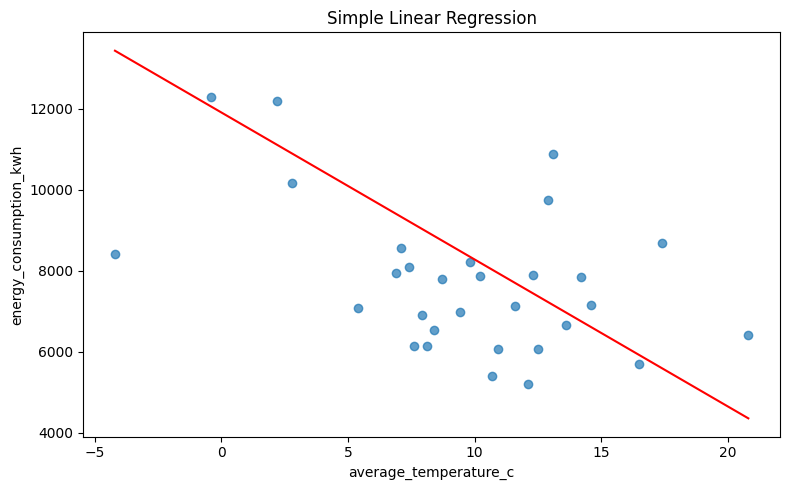

In [8]:
X_simple = X[['average_temperature_c']]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)
simple_model = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', LinearRegression())])
simple_results = evaluate_model('Simple Linear Regression', simple_model, X_train_s, X_test_s, y_train_s, y_test_s)

simple_model.fit(X_train_s, y_train_s)
plot_df = X_test_s.copy()
plot_df['pred'] = simple_model.predict(X_test_s)
plot_df = plot_df.sort_values('average_temperature_c')
plt.figure(figsize=(8,5))
plt.scatter(X_test_s['average_temperature_c'], y_test_s, alpha=0.7)
plt.plot(plot_df['average_temperature_c'], plot_df['pred'], color='red')
plt.title('Simple Linear Regression')
plt.xlabel('average_temperature_c'); plt.ylabel('energy_consumption_kwh')
plt.tight_layout(); plt.show()

## 9) Model 2: Multiple Linear Regression

Multiple linear regression still uses `LinearRegression()`, but now it uses all prepared features after preprocessing.

This lets us compare a one-feature model with a model that uses more information.


In [9]:
multiple_model = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
multiple_results = evaluate_model('Multiple Linear Regression', multiple_model, X_train, X_test, y_train, y_test)

## 10) Model 3: Polynomial Regression

`PolynomialFeatures(degree=2, include_bias=False)` creates squared and interaction terms from numeric features.

`degree=2` allows curved relationships. `include_bias=False` avoids adding an extra constant column because the regression model already handles the intercept.


In [10]:
poly_cols = ['average_temperature_c', 'house_size_m2', 'building_age_years']
X_poly = X[poly_cols]
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)
poly_model = Pipeline([('imputer', SimpleImputer(strategy='median')), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('scaler', StandardScaler()), ('model', LinearRegression())])
poly_results = evaluate_model('Polynomial Regression', poly_model, X_train_p, X_test_p, y_train_p, y_test_p)

## 11) Model 4: Ridge Regression

`Ridge(alpha=1.0)` is linear regression with L2 regularization.

`alpha` controls how strongly coefficients are shrunk. Ridge can improve stability when features are noisy or correlated.


In [11]:
ridge_model = Pipeline([('preprocessor', preprocessor), ('model', Ridge(alpha=1.0))])
ridge_results = evaluate_model('Ridge Regression', ridge_model, X_train, X_test, y_train, y_test)

## 12) Model 5: Lasso Regression

`Lasso(alpha=0.1, max_iter=10000)` is linear regression with L1 regularization.

Lasso can shrink some coefficients exactly to zero. `max_iter` gives the optimizer enough iterations to finish reliably.


In [12]:
lasso_model = Pipeline([('preprocessor', preprocessor), ('model', Lasso(alpha=0.1, max_iter=10000))])
lasso_results = evaluate_model('Lasso Regression', lasso_model, X_train, X_test, y_train, y_test)

## 13) Model comparison table

The table compares train and test performance for each model.

Look for both accuracy and generalization. A model with very low train error but much higher test error may be overfitting.


In [13]:
results = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_test_pred'} for r in [simple_results, multiple_results, poly_results, ridge_results, lasso_results]])
results = results[['Model','Train MAE','Test MAE','Train MSE','Test MSE','Train RMSE','Test RMSE','Train R2','Test R2']].sort_values('Test RMSE').reset_index(drop=True)
display(results.round(3))

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Polynomial Regression,1175.105,1060.714,2.207028e+06,2167889.892,1485.607,1472.376,0.868,0.302
1,Ridge Regression,1328.554,1488.912,4.633479e+06,3657210.102,2152.552,1912.383,0.722,-0.178
2,Lasso Regression,1353.770,1529.147,4.627498e+06,3884578.957,2151.162,1970.934,0.722,-0.251
3,Multiple Linear Regression,1353.962,1529.519,4.627497e+06,3886071.450,2151.162,1971.312,0.722,-0.252
4,Simple Linear Regression,1745.127,1595.589,1.271271e+07,3976278.588,3565.489,1994.061,0.237,-0.281


## 14) Visual model comparison

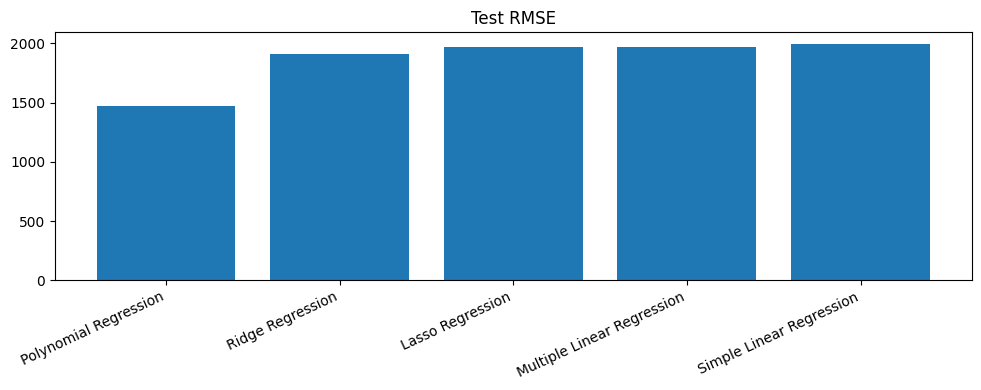

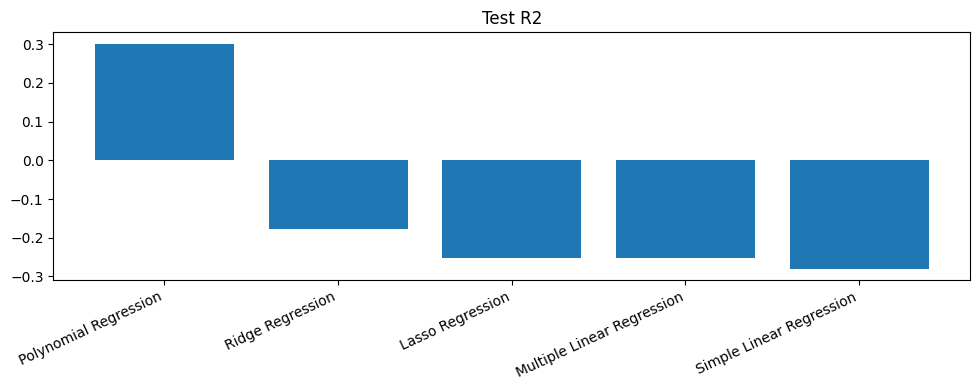

In [14]:
plt.figure(figsize=(10,4)); plt.bar(results['Model'], results['Test RMSE']); plt.xticks(rotation=25, ha='right'); plt.title('Test RMSE'); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,4)); plt.bar(results['Model'], results['Test R2']); plt.xticks(rotation=25, ha='right'); plt.title('Test R2'); plt.tight_layout(); plt.show()

## 15) Actual vs predicted plot

An actual vs predicted plot compares true target values on the x-axis with model predictions on the y-axis.

The dashed diagonal line represents perfect predictions. Points close to the line are better predictions.


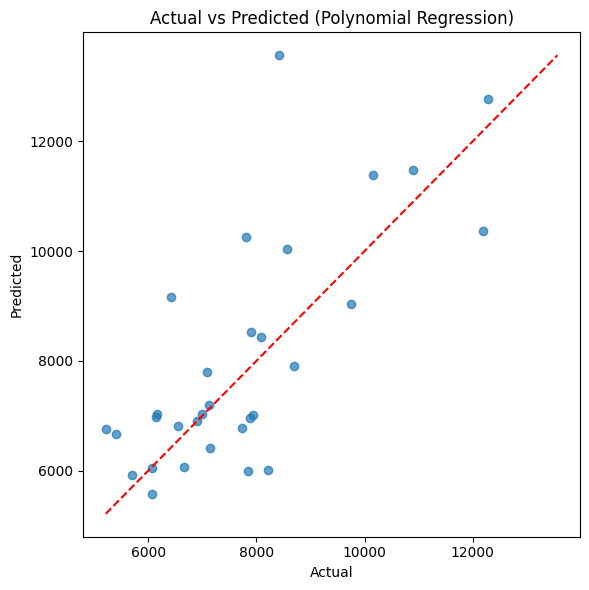

In [15]:
best_model_name = results.iloc[0]['Model']
result_map = {'Simple Linear Regression': simple_results, 'Multiple Linear Regression': multiple_results, 'Polynomial Regression': poly_results, 'Ridge Regression': ridge_results, 'Lasso Regression': lasso_results}
best_result = result_map[best_model_name]
y_pred_best = best_result['y_test_pred']
if best_model_name == 'Simple Linear Regression':
    y_test_best = y_test_s
elif best_model_name == 'Polynomial Regression':
    y_test_best = y_test_p
else:
    y_test_best = y_test

plt.figure(figsize=(6,6))
plt.scatter(y_test_best, y_pred_best, alpha=0.7)
mn, mx = min(y_test_best.min(), y_pred_best.min()), max(y_test_best.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title(f'Actual vs Predicted ({best_model_name})')
plt.tight_layout(); plt.show()

## 16) Residual analysis

Residuals are `actual - predicted`.

A residual plot helps us see whether errors are random or structured. A residual histogram shows the distribution of errors. Ideally, residuals are centered near zero without a strong pattern.


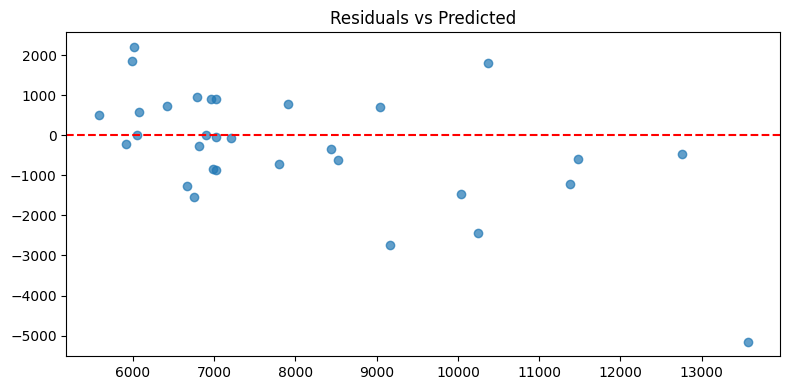

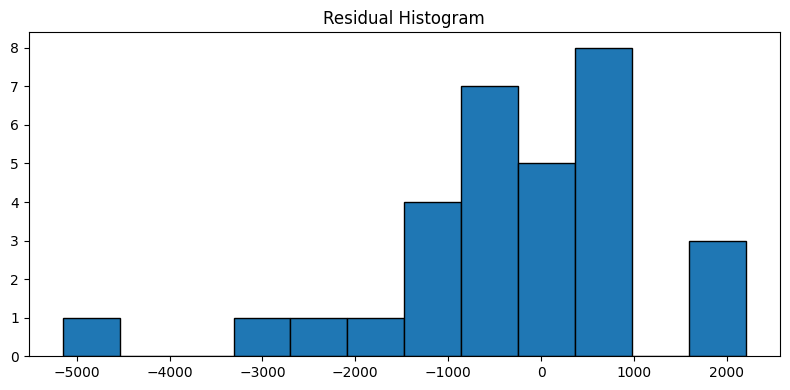

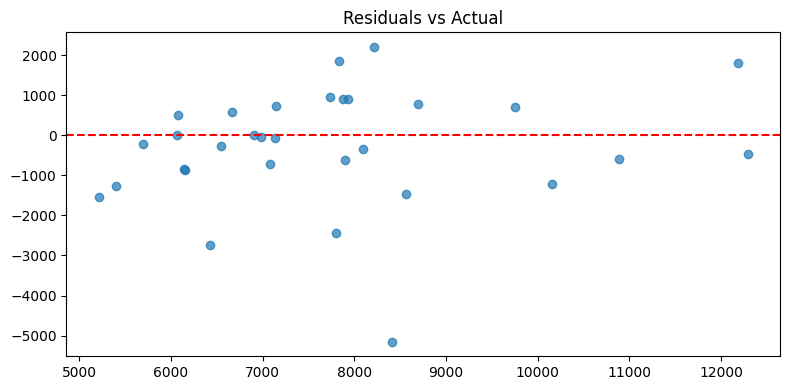

In [16]:
residuals = y_test_best - y_pred_best
plt.figure(figsize=(8,4)); plt.scatter(y_pred_best, residuals, alpha=0.7); plt.axhline(0, color='red', linestyle='--'); plt.title('Residuals vs Predicted'); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.hist(residuals, bins=12, edgecolor='black'); plt.title('Residual Histogram'); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.scatter(y_test_best, residuals, alpha=0.7); plt.axhline(0, color='red', linestyle='--'); plt.title('Residuals vs Actual'); plt.tight_layout(); plt.show()

Residual interpretation:
- random around zero: model is reasonable
- curved pattern: model may be too simple
- increasing spread: unequal variance
- large isolated points: possible outliers
- visible structure: missing features or wrong model form

## 17) Overfitting and underfitting reflection

Overfitting means the model learns the training data too closely and performs worse on test data. Underfitting means the model is too simple and performs poorly on both train and test data.

Use the train/test comparison table, actual vs predicted plot, and residual plots to decide whether the model looks reasonable.


## 18) Cross-validation final check

Cross-validation repeats training and validation on several folds.

`KFold(n_splits=5, shuffle=True, random_state=42)` creates five reproducible folds. `cross_val_score(scoring='neg_root_mean_squared_error')` returns RMSE scores as negative values because scikit-learn treats higher scores as better. We multiply by `-1` to read them as positive RMSE values.


In [17]:
model_map = {'Simple Linear Regression': simple_model, 'Multiple Linear Regression': multiple_model, 'Polynomial Regression': poly_model, 'Ridge Regression': ridge_model, 'Lasso Regression': lasso_model}
best_pipeline = model_map[best_model_name]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
if best_model_name == 'Simple Linear Regression':
    X_cv, y_cv = X_train_s, y_train_s
elif best_model_name == 'Polynomial Regression':
    X_cv, y_cv = X_train_p, y_train_p
else:
    X_cv, y_cv = X_train, y_train
try:
    cv_scores = cross_val_score(best_pipeline, X_cv, y_cv, cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores
except ValueError:
    cv_scores = cross_val_score(best_pipeline, X_cv, y_cv, cv=kf, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
print('RMSE per fold:', np.round(cv_rmse, 2))
print('Mean RMSE:', round(cv_rmse.mean(), 2))
print('Std RMSE:', round(cv_rmse.std(), 2))

RMSE per fold: [2535.68 1798.28 1575.71 4673.58 4296.53]
Mean RMSE: 2975.96
Std RMSE: 1278.07


In [18]:
print('Week 2 Day 3 Regression Models, Evaluation Metrics & Residual Analysis completed successfully.')

Week 2 Day 3 Regression Models, Evaluation Metrics & Residual Analysis completed successfully.


## Student Code Challenges

These questions are not only for answering in text. You should change the code, rerun the cell, compare the output, and explain what changed.

The cells in this final section are exercises. They are intentionally left unexecuted so students can run them during or after the practical session.


### Challenge 1 - Change the simple regression feature

**Question:**  
What happens if simple linear regression uses `house_size_m2` instead of `average_temperature_c`?

**Code:**


In [ ]:
# TODO: Replace average_temperature_c with house_size_m2 in the simple regression model.
# TODO: Rerun the model.
# TODO: Compare the metrics with the original simple model.


**Reflection:**  
Write 2-3 sentences comparing the original simple feature with the new one.


### Challenge 2 - Change polynomial degree

**Question:**  
What happens if polynomial regression uses degree 3 instead of degree 2?

**Code:**


In [ ]:
# TODO: Change PolynomialFeatures from degree=2 to degree=3.
# TODO: Rerun polynomial regression.
# TODO: Compare train/test RMSE and discuss possible overfitting.


**Reflection:**  
Write 2-3 sentences explaining whether the higher degree helped or overfit.


### Challenge 3 - Change Ridge alpha

**Question:**  
How do Ridge metrics change for alpha values 0.1, 1.0, and 10.0?

**Code:**


In [ ]:
# TODO: Test Ridge alpha values 0.1, 1.0, and 10.0.
# TODO: Compare RMSE and R2 for each value.
# TODO: Decide which alpha worked best.


**Reflection:**  
Write 2-3 sentences describing which alpha performed best and whether the differences were large.


### Challenge 4 - Change Lasso alpha

**Question:**  
Can a different Lasso alpha improve or worsen performance?

**Code:**


In [ ]:
# TODO: Test different Lasso alpha values.
# TODO: Compare RMSE and R2.
# TODO: Explain whether performance improves or worsens.


**Reflection:**  
Write 2-3 sentences explaining whether changing alpha improved the model.


### Challenge 5 - Interpret residuals

**Question:**  
Do the residuals for your chosen best model look random or structured?

**Code:**


In [ ]:
# TODO: Choose the model you think is best.
# TODO: Plot residuals for that model.
# TODO: Write 3-5 sentences about whether residuals look random or structured.


**Reflection:**  
Write 3-5 sentences explaining whether the residuals look random, curved, or unevenly spread.
